# 🤖 Trenowanie Modeli - Moodify

## 🎯 Cel
Wytrenowanie dwóch prostych modeli do rozpoznawania emocji:
- 📝 **Model Tekstowy** - scikit-learn (TF-IDF + klasyfikator)
- 📸 **Model Obrazowy** - TensorFlow/Keras (Transfer Learning)

---
# CZĘŚĆ 1: MODEL TEKSTOWY (scikit-learn)
---

## 1. Instalacja bibliotek

In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn

## 2. Import bibliotek

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

## 3. Wczytanie danych tekstowych

In [3]:
train_text = pd.read_csv('processed_data/train_text.csv')
val_text = pd.read_csv('processed_data/val_text.csv')
test_text = pd.read_csv('processed_data/test_text.csv')

print(f"Train: {len(train_text)}, Val: {len(val_text)}, Test: {len(test_text)}")
train_text.head()

Train: 16000, Val: 2000, Test: 2000


,text,emotion
0,i didnt feel humiliated,Smutek
1,i can go from feeling so hopeless to so damned...,Smutek
2,im grabbing a minute to post i feel greedy wrong,Złość
3,i am ever feeling nostalgic about the fireplac...,Szczęście
4,i am feeling grouchy,Złość


## 4. TF-IDF Vectorization

**Parametry:**
- max_features=5000: Top 5000 słów
- min_df=2: Słowo w min 2 dokumentach
- max_df=0.8: Ignoruj słowa w >80% dokumentów
- ngram_range=(1,2): Pojedyncze słowa i pary

In [4]:
vectorizer = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.8, ngram_range=(1, 2))

X_train = vectorizer.fit_transform(train_text['text'])
y_train = train_text['emotion']

X_val = vectorizer.transform(val_text['text'])
y_val = val_text['emotion']

X_test = vectorizer.transform(test_text['text'])
y_test = test_text['emotion']

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")
print(f"Słownik: {len(vectorizer.vocabulary_)} słów")

X_train: (16000, 5000), X_val: (2000, 5000), X_test: (2000, 5000)
Słownik: 5000 słów


## 5. Trening modelu SVM

In [5]:
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train, y_train)

val_accuracy = svm.score(X_val, y_val)
print(f"Validation Accuracy: {val_accuracy:.2%}")

Validation Accuracy: 90.80%


## 6. Ewaluacja na zbiorze testowym

In [6]:
y_pred = svm.predict(X_test)
report = classification_report(y_test, y_pred, output_dict=True)

print(f"Test Accuracy: {report['accuracy']:.2%}\n")
for emotion, metrics in report.items():
    if emotion not in ['accuracy', 'macro avg', 'weighted avg']:
        print(f"{emotion}: Precision={metrics['precision']:.2%}, Recall={metrics['recall']:.2%}, F1={metrics['f1-score']:.2%}")

Test Accuracy: 90.10%

Smutek: Precision=92.01%, Recall=91.22%, F1=91.62%
Strach: Precision=84.91%, Recall=80.36%, F1=82.57%
Szczęście: Precision=91.72%, Recall=97.31%, F1=94.43%
Zaskoczenie: Precision=70.00%, Recall=53.03%, F1=60.34%
Złość: Precision=88.28%, Recall=82.18%, F1=85.12%


## 7. Confusion Matrix

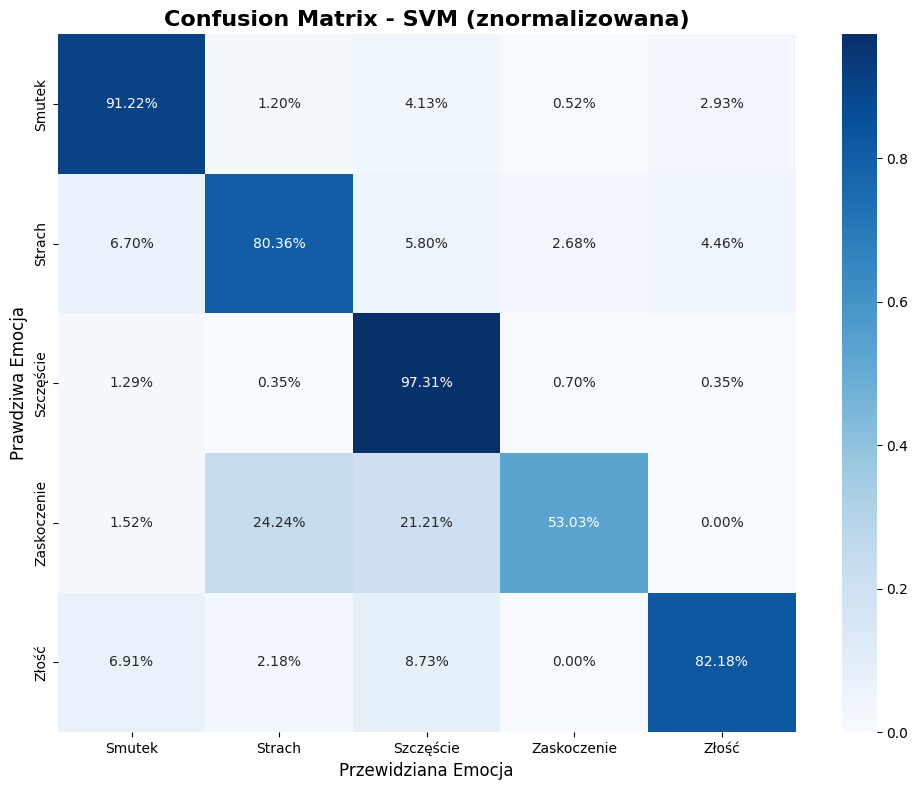

In [7]:
cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
emotions = sorted(train_text['emotion'].unique())

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=emotions,
            yticklabels=emotions)
plt.title('Confusion Matrix - SVM (znormalizowana)', fontsize=16, fontweight='bold')
plt.ylabel('Prawdziwa Emocja', fontsize=12)
plt.xlabel('Przewidziana Emocja', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Zapisanie modelu tekstowego

In [8]:
import os

os.makedirs('saved_models', exist_ok=True)
joblib.dump(svm, 'saved_models/svm_text_model.pkl')
joblib.dump(vectorizer, 'saved_models/tfidf_vectorizer.pkl')

print("✅ Model zapisany")

✅ Model zapisany


## 9. Test predykcji na nowych tekstach

In [9]:
def predict_emotion_text(text):
    return svm.predict(vectorizer.transform([text]))[0]

test_texts = [
    "I am so happy today!",
    "This is terrible, I hate it",
    "I'm feeling really sad and lonely",
    "Wow, I didn't expect that!",
    "I'm scared of what might happen"
]

for text in test_texts:
    print(f'"{text}" → {predict_emotion_text(text)}')

"I am so happy today!" → Szczęście
"This is terrible, I hate it" → Smutek
"I'm feeling really sad and lonely" → Smutek
"Wow, I didn't expect that!" → Szczęście
"I'm scared of what might happen" → Strach


---
# CZĘŚĆ 2: MODEL OBRAZOWY (TensorFlow/Keras)
---

## 10. Instalacja bibliotek

## 11. Import bibliotek TensorFlow

In [10]:
!pip install tensorflow[and-cuda] pillow keras-tuner

## 12. Konfiguracja CUDA

⚠️ Wykonać PRZED importem TensorFlow!

In [11]:
import os
import sys
from pathlib import Path
import ctypes

site_packages = None
for path in sys.path:
    if 'site-packages' in path:
        site_packages = Path(path)
        break

if site_packages:
    nvidia_libs_dirs = [
        site_packages / 'nvidia' / 'cuda_runtime' / 'lib',
        site_packages / 'nvidia' / 'cudnn' / 'lib', 
        site_packages / 'nvidia' / 'cublas' / 'lib',
        site_packages / 'nvidia' / 'cufft' / 'lib',
        site_packages / 'nvidia' / 'curand' / 'lib',
        site_packages / 'nvidia' / 'cusolver' / 'lib',
        site_packages / 'nvidia' / 'cusparse' / 'lib',
        site_packages / 'nvidia' / 'nvjitlink' / 'lib',
    ]
    
    new_paths = [str(p) for p in nvidia_libs_dirs if p.exists()]
    if new_paths:
        os.environ['LD_LIBRARY_PATH'] = ':'.join(new_paths) + (':' + os.environ.get('LD_LIBRARY_PATH', ''))
        for lib_dir in nvidia_libs_dirs:
            if lib_dir.exists():
                for so_file in lib_dir.glob('*.so*'):
                    if so_file.is_file() and not so_file.is_symlink():
                        try:
                            ctypes.CDLL(str(so_file), mode=ctypes.RTLD_GLOBAL)
                            break
                        except:
                            pass

print("✅ CUDA skonfigurowane")

✅ CUDA skonfigurowane


In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from PIL import Image

print(f"TensorFlow {tf.__version__}")
print(f"GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")

2025-11-26 18:48:55.029687: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow 2.20.0
GPU: True


## 13. Konfiguracja GPU

In [13]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✅ GPU: {len(gpus)} urządzeń")
else:
    print("⚠️ Brak GPU - trening na CPU")

✅ GPU: 1 urządzeń


## 14. Wczytanie danych obrazowych

In [14]:
train_img = pd.read_csv('processed_data/train_images.csv')
val_img = pd.read_csv('processed_data/val_images.csv')
test_img = pd.read_csv('processed_data/test_images.csv')

train_img = train_img[train_img['emotion'] != 'neutral'].reset_index(drop=True)
val_img = val_img[val_img['emotion'] != 'neutral'].reset_index(drop=True)
test_img = test_img[test_img['emotion'] != 'neutral'].reset_index(drop=True)

emotions_list = sorted(train_img['emotion'].unique())
emotion_to_id = {emotion: idx for idx, emotion in enumerate(emotions_list)}
id_to_emotion = {idx: emotion for emotion, idx in emotion_to_id.items()}

print(f"Train: {len(train_img)}, Val: {len(val_img)}, Test: {len(test_img)}")
print(f"Emocje: {emotions_list}")

Train: 14106, Val: 3023, Test: 3023
Emocje: ['Smutek', 'Strach', 'Szczęście', 'Zaskoczenie', 'Złość']


## 15. Wczytanie ścieżki bazowej

In [15]:
import json

with open('processed_data/data_paths.json', 'r') as f:
    data_paths = json.load(f)

BASE_PATH = data_paths['affectnet_base_path']
print(f"Ścieżka bazowa: {BASE_PATH}")

Ścieżka bazowa: /home/dupa/.cache/kagglehub/datasets/mstjebashazida/affectnet/versions/1


## 16. Generator danych

**Data augmentation:** flip, brightness, contrast, saturation, rotation, zoom, crop  
**Normalizacja:** [0, 1]  
**Labels:** one-hot encoding

In [16]:
from tensorflow.keras.utils import to_categorical

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 5

def create_dataset(df, emotion_to_id, base_path, augment=False):
    def load_image(path, label):
        full_path = tf.strings.join([base_path, os.sep, path])
        img = tf.io.read_file(full_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        return img / 255.0, label
    
    def augment_image(img, label):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, max_delta=0.2)
        img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
        img = tf.image.random_saturation(img, lower=0.8, upper=1.2)
        
        if tf.random.uniform([]) > 0.5:
            k = tf.random.uniform([], minval=0, maxval=4, dtype=tf.int32)
            img = tf.image.rot90(img, k=k % 4)
        
        zoom_factor = tf.random.uniform([], minval=0.9, maxval=1.1)
        new_size = tf.cast(IMG_SIZE * zoom_factor, tf.int32)
        img = tf.image.resize(img, [new_size, new_size])
        img = tf.image.resize_with_crop_or_pad(img, IMG_SIZE, IMG_SIZE)
        img = tf.image.random_crop(img, size=[IMG_SIZE, IMG_SIZE, 3])
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        return tf.clip_by_value(img, 0.0, 1.0), label
    
    labels = to_categorical(df['emotion'].map(emotion_to_id).values, num_classes=NUM_CLASSES)
    dataset = tf.data.Dataset.from_tensor_slices((df['path'].values, labels))
    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    
    if augment:
        dataset = dataset.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)
        dataset = dataset.shuffle(1000)
    
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = create_dataset(train_img, emotion_to_id, BASE_PATH, augment=True)
val_ds = create_dataset(val_img, emotion_to_id, BASE_PATH, augment=False)
test_ds = create_dataset(test_img, emotion_to_id, BASE_PATH, augment=False)

print("✅ Datasety gotowe")

I0000 00:00:1764179337.172043    6154 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4326 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060, pci bus id: 0000:09:00.0, compute capability: 7.5


✅ Datasety gotowe


## 17. Hyperparameter Tuning - Hyperband

**Cel:** val_accuracy ~75%+

**Analiza poprzednich wyników:**
- learning_rate=0.001 lub 0.0003 (najlepsze wyniki: 57%)
- units_2=192 (najczęściej w TOP 10)
- dropout_2=0.4 lub 0.3
- Poprzednio brak fine-tuningu CNN blokował accuracy

**Nowa strategia:**
- Fine-tuning ostatnich 20 warstw MobileNetV2 (cel: +15-20% accuracy)
- 8 kombinacji (mniej niż poprzednio, bo fine-tuning 2x wolniejszy)
- Max 45 min tunowania

In [ ]:
import keras_tuner as kt
from tensorflow.keras import regularizers
import datetime

def build_tuned_model(hp):
    base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
    
    unfreeze_layers = 20
    base_model.trainable = True
    for layer in base_model.layers[:-unfreeze_layers]:
        layer.trainable = False
    
    units_1 = hp.Choice('units_1', values=[256])
    units_2 = hp.Choice('units_2', values=[192])
    dropout_1 = hp.Choice('dropout_1', values=[0.3, 0.5])
    dropout_2 = hp.Choice('dropout_2', values=[0.3, 0.4])
    learning_rate = hp.Choice('learning_rate', values=[0.0003, 0.001])
    
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(units_1, activation='relu', kernel_regularizer=regularizers.l2(0.0001)),
        BatchNormalization(),
        Dropout(dropout_1),
        Dense(units_2, activation='relu', kernel_regularizer=regularizers.l2(0.0001)),
        BatchNormalization(),
        Dropout(dropout_2),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

log_dir = "keras_tuner/tensorboard_logs/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1, update_freq='epoch', profile_batch=0)

print(f"TensorBoard: tensorboard --logdir keras_tuner/tensorboard_logs")

tuner = kt.Hyperband(
    build_tuned_model,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    hyperband_iterations=1,
    directory='keras_tuner',
    project_name='moodify_hyperband_finetuned',
    overwrite=True,
    seed=42
)

early_stop_tuning = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1)
reduce_lr_tuning = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)

print("Rozpoczynam tunowanie z fine-tuningiem CNN (max 45 min)...")
print(f"Strategia: max_epochs=10, factor=3, 8 kombinacji")
print(f"Fine-tuning: ostatnie 20 warstw MobileNetV2")
print(f"Oczekiwany czas: ~40-45 min (~10-12 modeli, ~4 min/model)")
print(f"Oczekiwany wynik: 70-75% (vs poprzednie 57%)")

tuner.search(train_ds, validation_data=val_ds, epochs=10, callbacks=[early_stop_tuning, reduce_lr_tuning, tensorboard_callback], verbose=2)

best_models = tuner.get_best_hyperparameters(num_trials=3)
best_hps = best_models[0]

print("\nNajlepszy model:")
print(f"units_1={best_hps.get('units_1')}, units_2={best_hps.get('units_2')}")
print(f"dropout_1={best_hps.get('dropout_1'):.2f}, dropout_2={best_hps.get('dropout_2'):.2f}")
print(f"learning_rate={best_hps.get('learning_rate'):.6f}")
print(f"Fine-tuning: 20 ostatnich warstw MobileNetV2")

Trial 30 Complete [00h 03m 47s]
val_accuracy: 0.5603705048561096

Best val_accuracy So Far: 0.5706251859664917
Total elapsed time: 00h 48m 45s

🏆 Najlepszy model:
units_1=256, units_2=192
dropout_1=0.30, dropout_2=0.40
learning_rate=0.001000
units_1=256, units_2=192
dropout_1=0.30, dropout_2=0.40
learning_rate=0.001000


### Funkcja budująca model

**Fine-tuning:** Ostatnie 20 warstw MobileNetV2 odmrożone  
**Parametry do tunowania:**
- units_1: 256 (stałe - najlepsze z poprzednich)
- units_2: 192 (stałe - najlepsze)
- dropout_1: 0.3 lub 0.5
- dropout_2: 0.3 lub 0.4
- learning_rate: 0.0003 lub 0.001

**Kombinacji:** 8 (1×1×2×2×2)

In [18]:
model_image = tuner.hypermodel.build(best_hps)
model_image.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 192)            │        49,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 192)            │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           965 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,638,021 (10.06 MB)

 Trainable params: 379,141 (1.45 MB)

 Non-trainable params: 2,258,880 (8.62 MB)

## 18. Trening finalnego modelu

**Cel:** val_accuracy ~75%+  
**Czas:** max 45 min  
**Epoki:** 50 z early stopping (patience=5)  
**Strategia:** Fine-tuning CNN + długi trening (50 epok = ~40 min z fine-tuningiem)

In [ ]:
checkpoint = keras.callbacks.ModelCheckpoint('saved_models/image_model_best.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
early_stop = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)

print("Rozpoczynam finalne trenowanie (max 45 min)...")
print("Czas: ~0.8 min/epoka, max 50 epok = ~40 min")

history = model_image.fit(train_ds, validation_data=val_ds, epochs=50, callbacks=[checkpoint, early_stop, reduce_lr])

print(f"Najlepsza val_accuracy: {max(history.history['val_accuracy']):.2%}")
print(f"Wytrenowano w {len(history.history['accuracy'])} epokach")

🚀 Rozpoczynam finalne trenowanie (STRICT MAX 45 MIN)...
⏱️ ~2 min/epoka, max 20 epok = ~40 min
Epoch 1/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3691 - loss: 1.8578
Epoch 1: val_accuracy improved from None to 0.52001, saving model to saved_models/image_model_best.h5

Epoch 1: val_accuracy improved from None to 0.52001, saving model to saved_models/image_model_best.h5


441/441 ━━━━━━━━━━━━━━━━━━━━ 34s 59ms/step - accuracy: 0.4149 - loss: 1.6107 - val_accuracy: 0.5200 - val_loss: 1.2189 - learning_rate: 0.0010
Epoch 2/20
Epoch 2/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4695 - loss: 1.3308
Epoch 2: val_accuracy did not improve from 0.52001
441/441 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.4738 - loss: 1.3127 - val_accuracy: 0.4955 - val_loss: 1.2973 - learning_rate: 0.0010
Epoch 3/20

Epoch 2: val_accuracy did not improve from 0.52001
441/441 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.4738 - loss: 1.3127 - val_accuracy: 0.4955 - val_loss: 1.2973 - learning_rate: 0.0010
Epoch 3/20
439/441 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4980 - loss: 1.2445
Epoch 3: val_accuracy did not improve from 0.52001

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
441/441 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.5038 - loss: 1.2372 - val_accuracy: 0.5074 - val_loss: 1.2618 - learning_rate: 0.0010
E

441/441 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.5194 - loss: 1.2030 - val_accuracy: 0.5356 - val_loss: 1.1830 - learning_rate: 5.0000e-04
Epoch 5/20
Epoch 5/20
440/441 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5255 - loss: 1.1921
Epoch 5: val_accuracy improved from 0.53556 to 0.55276, saving model to saved_models/image_model_best.h5

Epoch 5: val_accuracy improved from 0.53556 to 0.55276, saving model to saved_models/image_model_best.h5


441/441 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.5328 - loss: 1.1774 - val_accuracy: 0.5528 - val_loss: 1.1099 - learning_rate: 5.0000e-04
Epoch 6/20
Epoch 6/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5368 - loss: 1.1776
Epoch 6: val_accuracy did not improve from 0.55276
441/441 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.5364 - loss: 1.1695 - val_accuracy: 0.5266 - val_loss: 1.2377 - learning_rate: 5.0000e-04
Epoch 7/20

Epoch 6: val_accuracy did not improve from 0.55276
441/441 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.5364 - loss: 1.1695 - val_accuracy: 0.5266 - val_loss: 1.2377 - learning_rate: 5.0000e-04
Epoch 7/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5434 - loss: 1.1582
Epoch 7: val_accuracy did not improve from 0.55276

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
441/441 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.5407 - loss: 1.1594 - val_accuracy: 0.5382 - val_loss: 1.1883 - learning_ra

441/441 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.5493 - loss: 1.1373 - val_accuracy: 0.5544 - val_loss: 1.1180 - learning_rate: 2.5000e-04
Epoch 9/20
Epoch 9/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5546 - loss: 1.1333
Epoch 9: val_accuracy did not improve from 0.55442

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
441/441 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.5505 - loss: 1.1315 - val_accuracy: 0.5432 - val_loss: 1.1541 - learning_rate: 2.5000e-04
Epoch 10/20

Epoch 9: val_accuracy did not improve from 0.55442

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
441/441 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.5505 - loss: 1.1315 - val_accuracy: 0.5432 - val_loss: 1.1541 - learning_rate: 2.5000e-04
Epoch 10/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5488 - loss: 1.1258
Epoch 10: val_accuracy improved from 0.55442 to 0.55805, saving model to saved_models/image_model_best.h

...

441/441 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.5699 - loss: 1.1001 - val_accuracy: 0.5643 - val_loss: 1.1072 - learning_rate: 6.2500e-05
Epoch 13/20
Epoch 13/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5727 - loss: 1.1001
Epoch 13: val_accuracy improved from 0.56434 to 0.56500, saving model to saved_models/image_model_best.h5

Epoch 13: val_accuracy improved from 0.56434 to 0.56500, saving model to saved_models/image_model_best.h5


441/441 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.5733 - loss: 1.0963 - val_accuracy: 0.5650 - val_loss: 1.1010 - learning_rate: 6.2500e-05
Epoch 14/20
Epoch 14/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5682 - loss: 1.0965
Epoch 14: val_accuracy did not improve from 0.56500
441/441 ━━━━━━━━━━━━━━━━━━━━ 39s 87ms/step - accuracy: 0.5697 - loss: 1.0920 - val_accuracy: 0.5633 - val_loss: 1.0968 - learning_rate: 6.2500e-05
Epoch 15/20

Epoch 14: val_accuracy did not improve from 0.56500
441/441 ━━━━━━━━━━━━━━━━━━━━ 39s 87ms/step - accuracy: 0.5697 - loss: 1.0920 - val_accuracy: 0.5633 - val_loss: 1.0968 - learning_rate: 6.2500e-05
Epoch 15/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5742 - loss: 1.0970
Epoch 15: val_accuracy improved from 0.56500 to 0.56798, saving model to saved_models/image_model_best.h5

Epoch 15: val_accuracy improved from 0.56500 to 0.56798, saving model to saved_models/image_model_best.h5


441/441 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.5773 - loss: 1.0865 - val_accuracy: 0.5680 - val_loss: 1.0978 - learning_rate: 6.2500e-05
Epoch 16/20
Epoch 16/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5679 - loss: 1.1029
Epoch 16: val_accuracy improved from 0.56798 to 0.57162, saving model to saved_models/image_model_best.h5

Epoch 16: val_accuracy improved from 0.56798 to 0.57162, saving model to saved_models/image_model_best.h5


441/441 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.5722 - loss: 1.0930 - val_accuracy: 0.5716 - val_loss: 1.0866 - learning_rate: 6.2500e-05
Epoch 17/20
Epoch 17/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5659 - loss: 1.0930
Epoch 17: val_accuracy did not improve from 0.57162
441/441 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.5730 - loss: 1.0839 - val_accuracy: 0.5706 - val_loss: 1.0899 - learning_rate: 6.2500e-05
Epoch 18/20

Epoch 17: val_accuracy did not improve from 0.57162
441/441 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.5730 - loss: 1.0839 - val_accuracy: 0.5706 - val_loss: 1.0899 - learning_rate: 6.2500e-05
Epoch 18/20
439/441 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5744 - loss: 1.0809
Epoch 18: val_accuracy did not improve from 0.57162
441/441 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.5793 - loss: 1.0755 - val_accuracy: 0.5713 - val_loss: 1.0838 - learning_rate: 6.2500e-05

Epoch 18: val_accuracy did not improve from 0.57162
44

441/441 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.5757 - loss: 1.0712 - val_accuracy: 0.5736 - val_loss: 1.0770 - learning_rate: 6.2500e-05
Restoring model weights from the end of the best epoch: 20.
Restoring model weights from the end of the best epoch: 20.
✅ Najlepsza val_accuracy: 57.36%
Wytrenowano w 20 epokach
✅ Najlepsza val_accuracy: 57.36%
Wytrenowano w 20 epokach


## 19. Wykresy treningu

In [20]:
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
difference = final_train_acc - final_val_acc

print(f"Train: {final_train_acc:.2%}, Val: {final_val_acc:.2%}, Różnica: {difference:.2%}")

if difference < 0.05:
    print("🟢 GOOD FIT")
elif difference < 0.10:
    print("🟡 SLIGHT OVERFITTING")
else:
    print("🔴 OVERFITTING")

Train: 57.57%, Val: 57.36%, Różnica: 0.21%
🟢 GOOD FIT


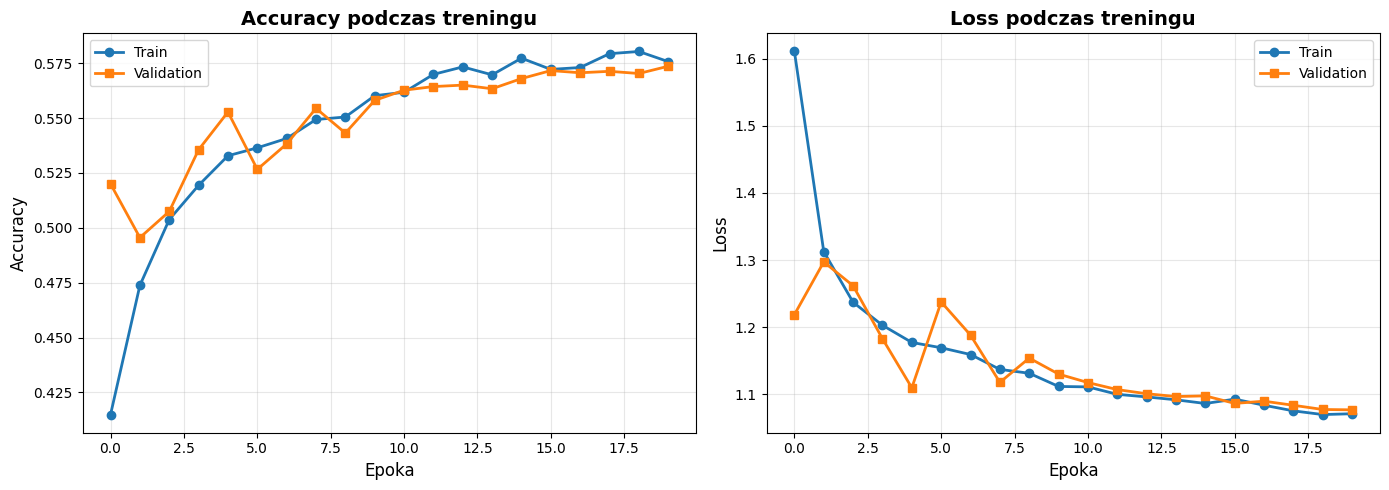

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], marker='o', label='Train', linewidth=2)
ax1.plot(history.history['val_accuracy'], marker='s', label='Validation', linewidth=2)
ax1.set_title('Accuracy podczas treningu', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoka', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history.history['loss'], marker='o', label='Train', linewidth=2)
ax2.plot(history.history['val_loss'], marker='s', label='Validation', linewidth=2)
ax2.set_title('Loss podczas treningu', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoka', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 20. Ewaluacja na zbiorze testowym

In [22]:
model_image = keras.models.load_model('saved_models/image_model_best.h5')
test_loss, test_acc = model_image.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.2%}")

95/95 ━━━━━━━━━━━━━━━━━━━━ 26s 132ms/step - accuracy: 0.6054 - loss: 1.0451
Test Accuracy: 60.54%
95/95 ━━━━━━━━━━━━━━━━━━━━ 26s 132ms/step - accuracy: 0.6054 - loss: 1.0451
Test Accuracy: 60.54%


## 21. Confusion Matrix

2025-11-26 19:54:30.929047: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


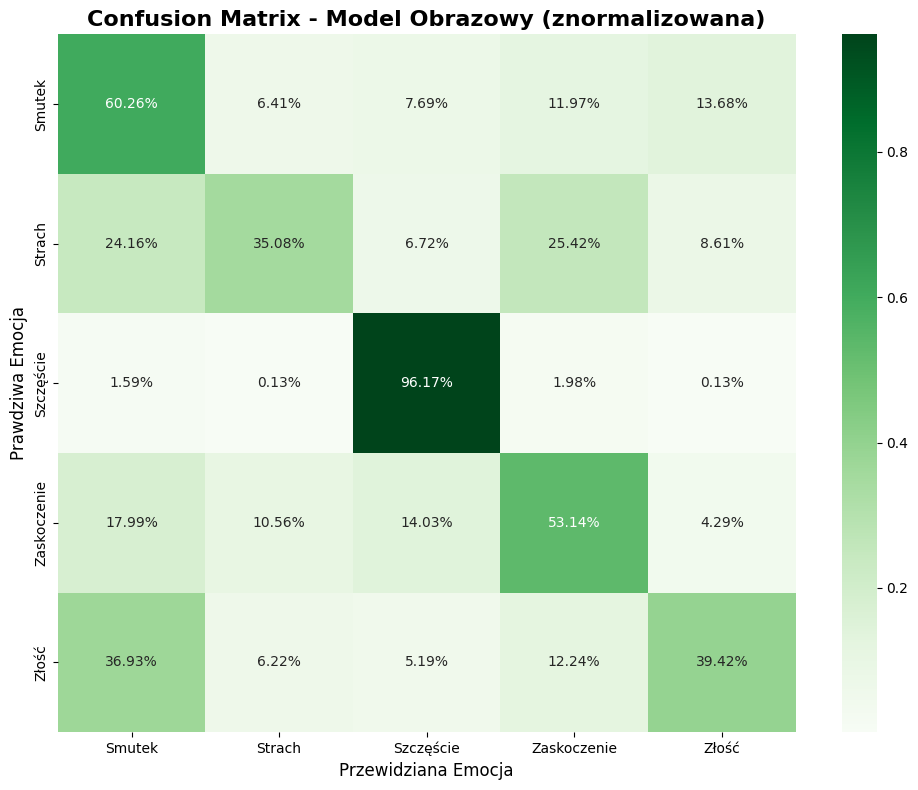

Smutek: Precision=50.54%, Recall=60.26%, F1=54.97%
Strach: Precision=54.40%, Recall=35.08%, F1=42.66%
Szczęście: Precision=78.79%, Recall=96.17%, F1=86.62%
Zaskoczenie: Precision=53.58%, Recall=53.14%, F1=53.36%
Złość: Precision=53.67%, Recall=39.42%, F1=45.45%

Accuracy: 60.54%


In [26]:
y_pred = []
y_true = []

for images, labels in test_ds:
    preds = model_image.predict(images, verbose=0)
    y_pred.extend(preds.argmax(axis=1))
    y_true.extend(labels.numpy().argmax(axis=1))

cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens', xticklabels=emotions_list, yticklabels=emotions_list)
plt.title('Confusion Matrix - Model Obrazowy (znormalizowana)', fontsize=16, fontweight='bold')
plt.ylabel('Prawdziwa Emocja', fontsize=12)
plt.xlabel('Przewidziana Emocja', fontsize=12)
plt.tight_layout()
plt.show()

report = classification_report(y_true, y_pred, target_names=emotions_list, output_dict=True)
for emotion in emotions_list:
    m = report[emotion]
    print(f"{emotion}: Precision={m['precision']:.2%}, Recall={m['recall']:.2%}, F1={m['f1-score']:.2%}")
print(f"\nAccuracy: {report['accuracy']:.2%}")

## 22. Zapisanie finalnego modelu

In [24]:
import json

model_image.save('saved_models/image_model_final.h5')
with open('saved_models/image_emotion_map.json', 'w') as f:
    json.dump(id_to_emotion, f)

print("✅ Model zapisany")

✅ Model zapisany
